# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.cluster import KElbowVisualizer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [43]:
# Membaca data
path = "D:/Dicoding/Machine Learning/Submission/synthetic_beverage_sales_data.csv"
df = pd.read_csv(path)

df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


In [44]:
df.tail()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
49995,ORD16765,CUS6053,B2C,Cranberry Juice,Juices,3.67,2,0.0,7.34,Hessen,2023-06-15
49996,ORD16765,CUS6053,B2C,Passion Fruit Juice,Juices,3.11,12,0.0,37.32,Hessen,2023-06-15
49997,ORD16765,CUS6053,B2C,Apollinaris,Water,0.99,8,0.0,7.92,Hessen,2023-06-15
49998,ORD16766,CUS1880,B2C,Riesling,Alcoholic Beverages,4.07,11,0.0,44.77,Rheinland-Pfalz,2021-05-12
49999,ORD16766,CUS1880,B2C,Selters,Water,0.46,9,0.0,4.14,Rheinland-Pfalz,2021-05-12


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       50000 non-null  object 
 1   Customer_ID    50000 non-null  object 
 2   Customer_Type  50000 non-null  object 
 3   Product        50000 non-null  object 
 4   Category       50000 non-null  object 
 5   Unit_Price     50000 non-null  float64
 6   Quantity       50000 non-null  int64  
 7   Discount       50000 non-null  float64
 8   Total_Price    50000 non-null  float64
 9   Region         50000 non-null  object 
 10  Order_Date     50000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 4.2+ MB


In [46]:
df.describe(include='all').round(2)

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
count,50000,50000,50000,50000,50000,50000.00,50000.00,50000.00,50000.00,50000,50000
unique,16766,8157,2,47,4,NaN,NaN,NaN,NaN,16,1094
top,ORD1,CUS4566,B2C,Mango Juice,Soft Drinks,NaN,NaN,NaN,NaN,Bremen,2021-06-16
freq,5,33,32160,1837,12562,NaN,NaN,NaN,NaN,3334,89
mean,NaN,NaN,NaN,NaN,NaN,5.75,23.12,0.03,128.72,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.58,26.87,0.04,503.69,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.32,1.00,0.00,0.38,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.06,6.00,0.00,8.48,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.75,11.00,0.00,21.14,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3.21,30.00,0.05,69.00,NaN,NaN


In [47]:
df.isnull().sum()

Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int64

In [48]:
print('Jumlah data terduplikat:', df.duplicated())

Jumlah data terduplikat: 0        False
1        False
2        False
3        False
4        False
5        False
6        False
7        False
8        False
9        False
10       False
11       False
12       False
13       False
14       False
15       False
16       False
17       False
18       False
19       False
20       False
21       False
22       False
23       False
24       False
25       False
26       False
27       False
28       False
29       False
30       False
31       False
32       False
33       False
34       False
35       False
36       False
37       False
38       False
39       False
40       False
41       False
42       False
43       False
44       False
45       False
46       False
47       False
48       False
49       False
50       False
51       False
52       False
53       False
54       False
55       False
56       False
57       False
58       False
59       False
60       False
61       False
62       False
63       False
64       False


In [49]:
numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns
interger_features = df.select_dtypes(include=['int64']).columns
float_features = df.select_dtypes(include=['float64']).columns
int_float_features = df.select_dtypes(include=['int64', 'float64']).columns

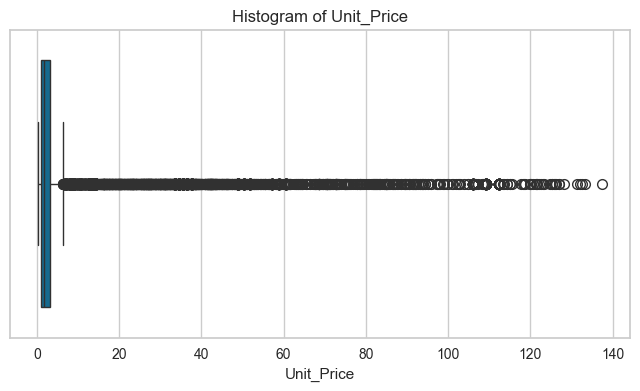

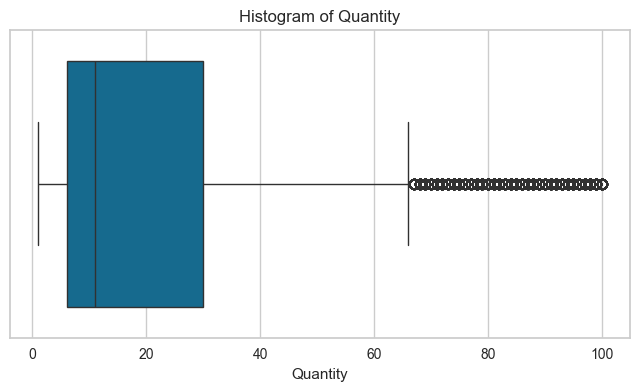

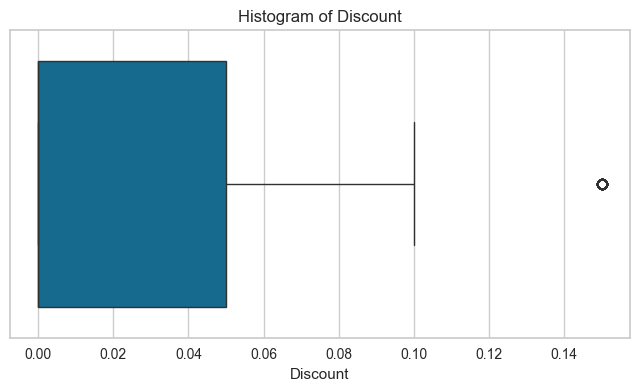

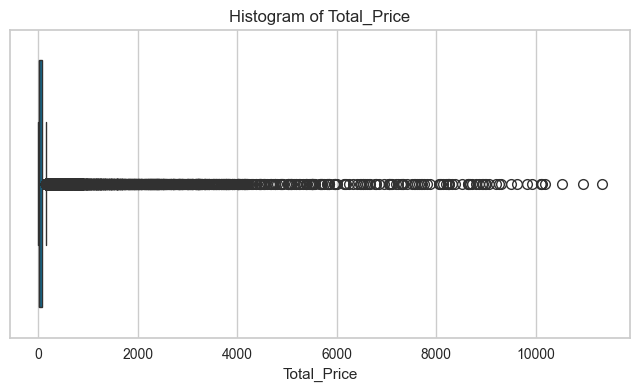

In [50]:
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Histogram of {feature}')
    plt.show()

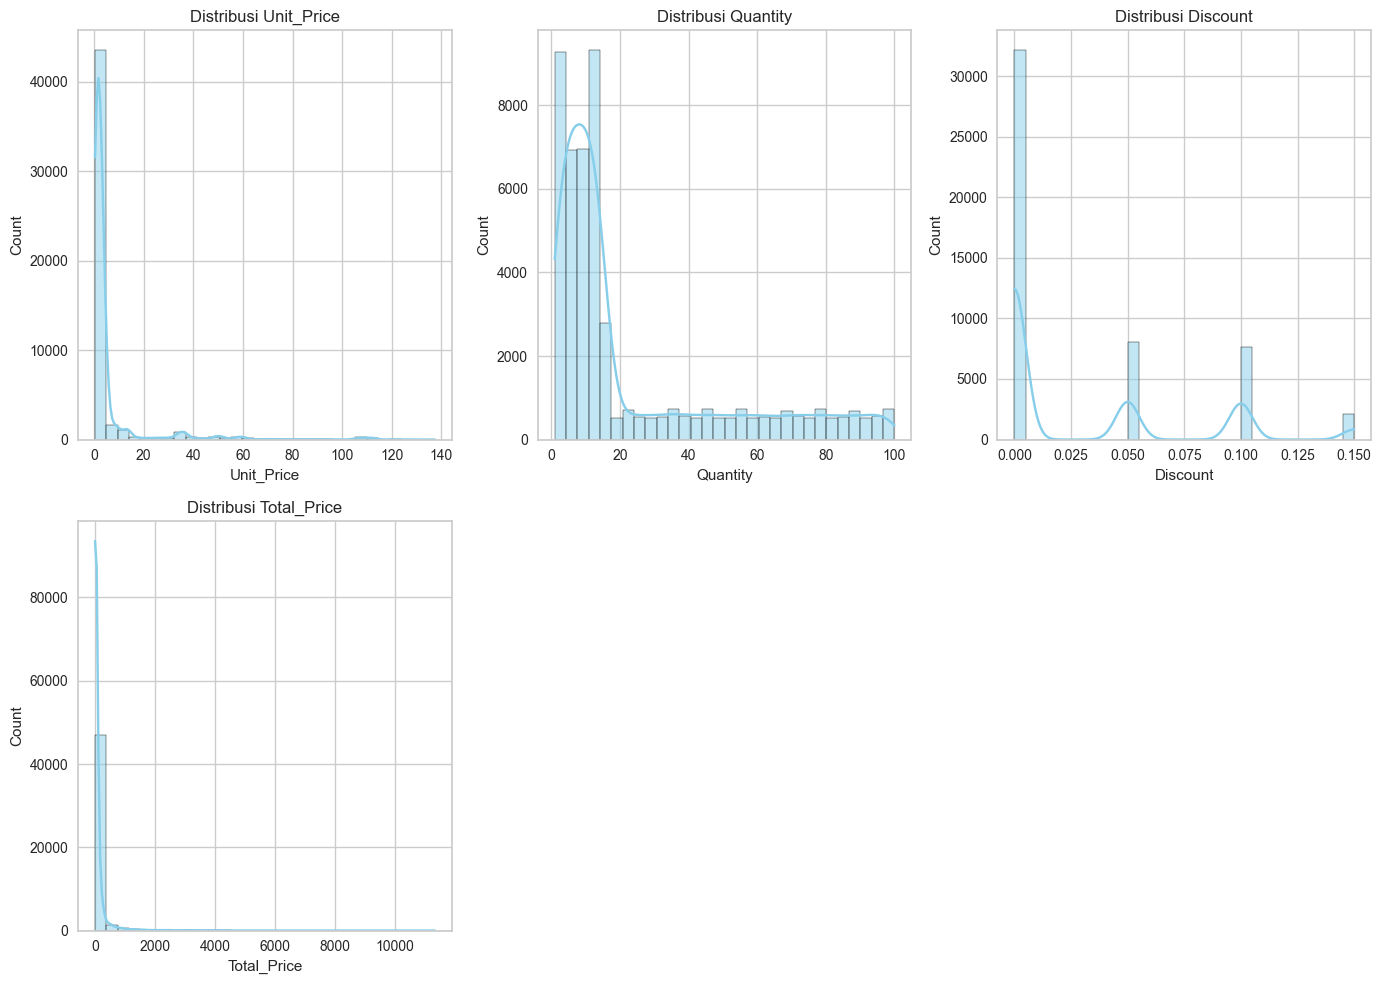

In [51]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[column], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

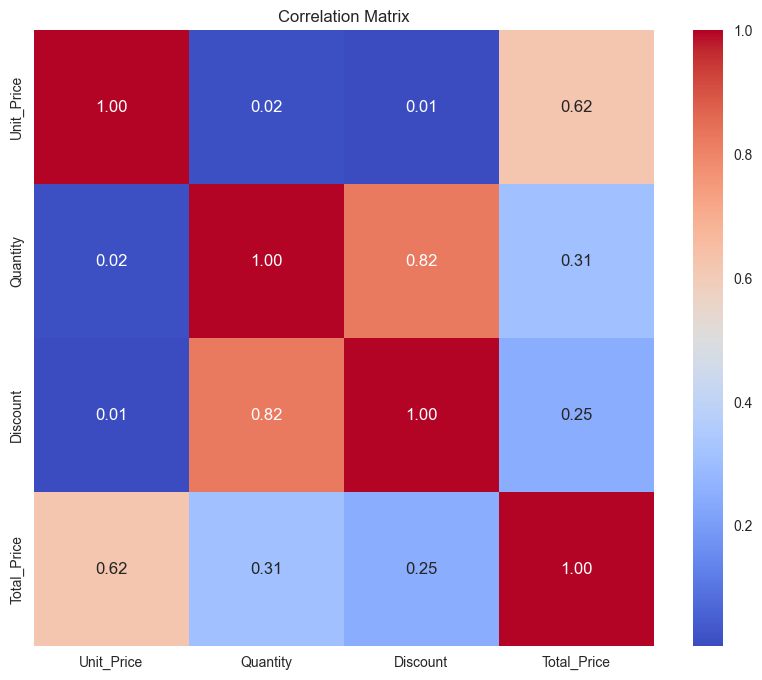

In [52]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\4266151970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, ax=axes[0], palette='viridis')
C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\4266151970.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Customer_Type', data=df, ax=axes[1], palette='viridis')


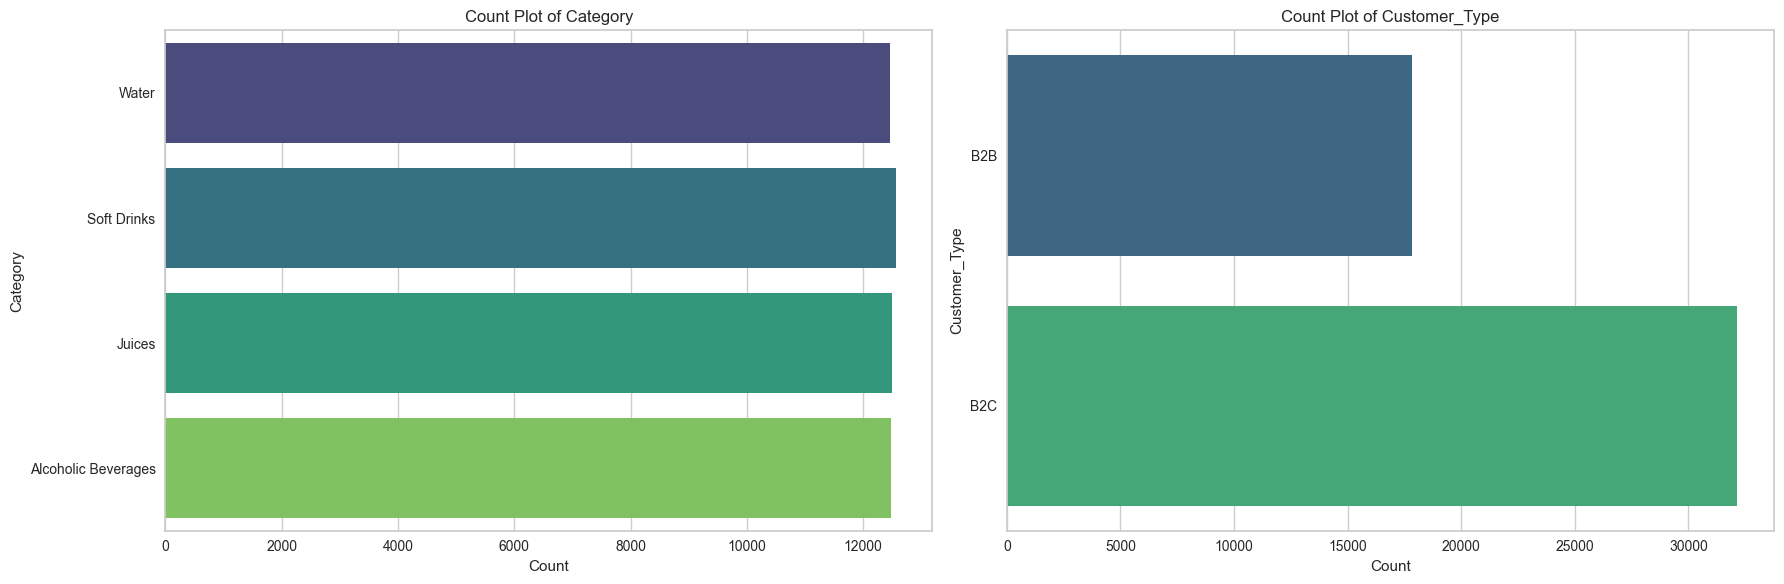

In [53]:
# Buat figure dan axes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot untuk kolom 'Gender'
sns.countplot(y='Category', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Count Plot of Category')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Category')

# Plot untuk kolom 'smoking_history'
sns.countplot(y='Customer_Type', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Count Plot of Customer_Type')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Customer_Type')

# Atur tata letak plot
plt.tight_layout()
plt.show()

In [54]:
df.groupby(by='Region').Customer_ID.nunique().sort_values(ascending=False)

Region
Hamburg                   570
Niedersachsen             521
Rheinland-Pfalz           521
Bremen                    520
Nordrhein-Westfalen       520
Baden-Württemberg         517
Schleswig-Holstein        513
Saarland                  507
Mecklenburg-Vorpommern    506
Sachsen                   505
Sachsen-Anhalt            505
Thüringen                 498
Bayern                    493
Hessen                    491
Brandenburg               488
Berlin                    482
Name: Customer_ID, dtype: int64

In [55]:
df.Customer_Type.value_counts()

Customer_Type
B2C    32160
B2B    17840
Name: count, dtype: int64

In [56]:
df.Product.value_counts()

Product
Mango Juice            1837
Hohes C Orange         1835
Tomato Juice           1801
Cranberry Juice        1775
Granini Apple          1756
Rauch Multivitamin     1747
Passion Fruit Juice    1745
Selters                1426
Volvic Touch           1419
San Pellegrino         1392
Vittel                 1391
Gerolsteiner           1384
Vio Wasser             1375
Apollinaris            1370
Volvic                 1356
Evian                  1348
Fritz-Kola             1301
Sprite                 1139
Coca-Cola              1120
Fanta                  1099
Red Bull               1029
Club Mate              1012
Monster                1012
Mountain Dew            990
Pepsi                   979
Mezzo Mix               964
Schwip Schwap           959
Rockstar                958
Beck's                  775
Rotkäppchen Sekt        730
Riesling                729
Kölsch                  680
Tanqueray               675
Krombacher              673
Jever                   661
Chardonnay  

In [57]:
df.groupby(by='Region').Order_ID.nunique().sort_values(ascending=False).reset_index()

,Region,Order_ID
0,Hamburg,1125
1,Bremen,1111
2,Rheinland-Pfalz,1084
3,Baden-Württemberg,1083
4,Nordrhein-Westfalen,1065
5,Sachsen-Anhalt,1062
6,Mecklenburg-Vorpommern,1058
7,Niedersachsen,1046
8,Sachsen,1043
9,Thüringen,1040


In [58]:
df.groupby(by='Product').agg({
    'Quantity' : 'sum',
    'Total_Price' : ['min', 'max']
})

Quantity Total_Price          
                         sum         min       max
Product                                           
Apollinaris            31954        0.44    140.94
Augustiner             14063        1.09    313.63
Bacardi                13466       13.44   3835.76
Beck's                 18233        1.00    213.01
Chardonnay             15334        3.66   1456.06
Club Mate              24143        1.80    233.96
Coca-Cola              25119        0.54    148.61
Cranberry Juice        41764        2.02    388.33
Erdinger Weißbier      15441        1.05    294.98
Evian                  32041        0.63    169.29
Fanta                  25520        0.58    150.30
Fritz-Kola             29031        1.99    304.20
Gerolsteiner           31328        0.42    141.42
Granini Apple          40294        1.24    253.94
Havana Club            14947       12.58   4099.50
Hohes C Orange         40954        1.14    300.96
Jack Daniels           12808       32.99   4717.30
Jever                  16104        1.36    199.75
Johnnie Walker         15657       27.53   5533.20
Krombacher             16391        1.54    189.61
Kölsch                 14934        0.93    232.55
Mango Juice            41068        2.03    396.48
Merlot                 15431        3.64   1351.76
Mezzo Mix              23050        0.59    155.23
Monster                23141        1.99    373.63
Mountain Dew           22702        0.54    153.47
Moët & Chandon         14812       42.03  11325.33
Passion Fruit Juice    40334        2.20    400.43
Pepsi                  22667        0.79    153.90
Rauch Multivitamin     38332        2.31    350.15
Red Bull               25340        2.17    358.80
Riesling               16099        3.52   1513.02
Rockstar               22519        1.71    364.04
Rotkäppchen Sekt       17004        3.28   1001.48
San Pellegrino         33551        0.40    148.95
Sauvignon Blanc        15388        4.44   1416.01
Schwip Schwap          22461        0.61    148.10
Selters                33260        0.40    144.49
Sprite                 27386        0.53    151.47
Tanqueray              14720       18.03   4523.73
Tomato Juice           42963        1.61    351.00
Veuve Clicquot         14000       32.86  10949.13
Vio Wasser             32178        0.53    192.04
Vittel                 31508        0.38    102.82
Volvic                 30507        0.55    102.14
Volvic Touch           32368        0.51    199.22
Warsteiner             13452        1.02    199.04

In [59]:
pd.set_option('display.max_rows', None)

df.groupby(by=['Region', 'Product']).agg({
    'Quantity' : 'sum',
    'Total_Price' : 'sum'
})

Quantity  Total_Price
Region                 Product                                   
Baden-Württemberg      Apollinaris              2099      1896.55
                       Augustiner                770      1429.93
                       Bacardi                  1207     28376.86
                       Beck's                    668       939.90
                       Chardonnay               1125      9570.96
                       Club Mate                1827      3655.36
                       Coca-Cola                2201      2332.38
                       Cranberry Juice          3174     10360.17
                       Erdinger Weißbier         855      1755.57
                       Evian                    2060      2330.05
                       Fanta                    1696      1816.88
                       Fritz-Kola               1411      3228.41
                       Gerolsteiner             1852      1677.82
                       Granini Apple            2421      3919.43
                       Havana Club               722     15103.52
                       Hohes C Orange           2413      4817.74
                       Jack Daniels             1016     35888.10
                       Jever                     881      1297.91
                       Johnnie Walker           1148     40881.05
                       Krombacher               1195      1695.52
                       Kölsch                   1254      1861.29
                       Mango Juice              2432      7579.38
                       Merlot                    967      7598.96
                       Mezzo Mix                1641      1549.81
                       Monster                  1766      4907.66
                       Mountain Dew             1355      1283.41
                       Moët & Chandon            987     69970.83
                       Passion Fruit Juice      2806      8829.26
                       Pepsi                    1353      1623.50
                       Rauch Multivitamin       2438      6117.65
                       Red Bull                 1329      3387.88
                       Riesling                  739      6280.13
                       Rockstar                 1278      3101.05
                       Rotkäppchen Sekt         1147      6920.28
                       San Pellegrino           2036      1869.58
                       Sauvignon Blanc          1178      9852.76
                       Schwip Schwap            1384      1436.67
                       Selters                  1743      1220.71
                       Sprite                   2140      2070.27
                       Tanqueray                 861     26128.48
                       Tomato Juice             3674      9954.28
                       Veuve Clicquot            945     68672.18
                       Vio Wasser               1738      2366.31
                       Vittel                   2028      1368.93
                       Volvic                   1452       864.92
                       Volvic Touch             2156      2702.60
                       Warsteiner               1093      1401.59
Bayern                 Apollinaris              2334      2014.28
                       Augustiner                590       836.91
                       Bacardi                   459      9595.69
                       Beck's                    904      1271.95
                       Chardonnay                958      7084.54
                       Club Mate                1429      2790.33
                       Coca-Cola                1361      1400.70
                       Cranberry Juice          2512      8008.39
                       Erdinger Weißbier        1283      2530.08
                       Evian                    1544      1707.98
                       Fanta                    1885      1968.32
                       Fritz-Kola               1196      2636.06
                  

In [60]:
df.groupby(by=['Customer_Type', 'Product']).agg({
    'Quantity' : 'sum',
    'Total_Price' : 'sum'
})

Quantity  Total_Price
Customer_Type Product                                   
B2B           Apollinaris             24825     21310.94
              Augustiner              10728     20952.77
              Bacardi                 10466    256741.75
              Beck's                  14126     20177.69
              Chardonnay              12036    106157.99
              Club Mate               19139     38134.41
              Coca-Cola               19330     19398.57
              Cranberry Juice         32799     99213.99
              Erdinger Weißbier       11961     24039.07
              Evian                   25241     28346.54
              Fanta                   19598     19600.60
              Fritz-Kola              22107     51752.95
              Gerolsteiner            24102     21206.02
              Granini Apple           31033     54158.57
              Havana Club             11678    284030.58
              Hohes C Orange          31352     62133.18
              Jack Daniels             9673    298927.22
              Jever                   12779     17664.59
              Johnnie Walker          12422    458950.74
              Krombacher              13004     17570.62
              Kölsch                  11506     18159.02
              Mango Juice             31537     94340.67
              Merlot                  12126    103028.15
              Mezzo Mix               18216     18255.21
              Monster                 17854     46383.04
              Mountain Dew            18016     17910.43
              Moët & Chandon          11717    797150.08
              Passion Fruit Juice     31617     94148.44
              Pepsi                   17684     17824.98
              Rauch Multivitamin      28782     72205.05
              Red Bull                19969     52352.58
              Riesling                12404    113984.68
              Rockstar                17631     46250.24
              Rotkäppchen Sekt        13237     84101.03
              San Pellegrino          26593     23051.83
              Sauvignon Blanc         12146    106080.53
              Schwip Schwap           17751     17535.53
              Selters                 25774     22008.87
              Sprite                  21520     21946.73
              Tanqueray               11194    342022.00
              Tomato Juice            33760     84563.15
              Veuve Clicquot          10773    713426.28
              Vio Wasser              24994     30339.15
              Vittel                  24026     15713.89
              Volvic                  23281     14933.97
              Volvic Touch            25037     31225.44
              Warsteiner              10308     13991.93
B2C           Apollinaris              7129      6837.24
              Augustiner               3335      3749.45
              Bacardi                  3000     41556.58
              Beck's                   4107      5759.76
              Chardonnay               3298     16119.14
              Club Mate                5004     10976.39
              Coca-Cola                5789      6347.41
              Cranberry Juice          8965     31923.92
              Erdinger Weißbier        3480      7074.91
              Evian                    6800      8614.96
              Fanta                    5922      7069.59
              Fritz-Kola               6924     14215.22
              Gerolsteiner             7226      7520.80
              Granini Apple            9261     15175.39
              Havana Club              3269     42382.72
              Hohes C Orange           9602     17321.91
              Jack Daniels             3135    157323.21
              Jever                    3325      6448.87
              Johnnie Walker           3235    118103.50
              Krombacher               3387      5370.96
              Kölsch                   3428      3290.49
              Mango Juice              9531  

In [61]:
sum_order_items_df = df.groupby("Product").Quantity.sum().sort_values(ascending=False).reset_index()
sum_order_items_df.head(15)

,Product,Quantity
0,Tomato Juice,42963
1,Cranberry Juice,41764
2,Mango Juice,41068
3,Hohes C Orange,40954
4,Passion Fruit Juice,40334
5,Granini Apple,40294
6,Rauch Multivitamin,38332
7,San Pellegrino,33551
8,Selters,33260
9,Volvic Touch,32368


C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\278204463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Quantity", y="Product", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\278204463.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Quantity", y="Product", data=sum_order_items_df.sort_values(by="Quantity", ascending=True).head(5), palette=colors, ax=ax[1])


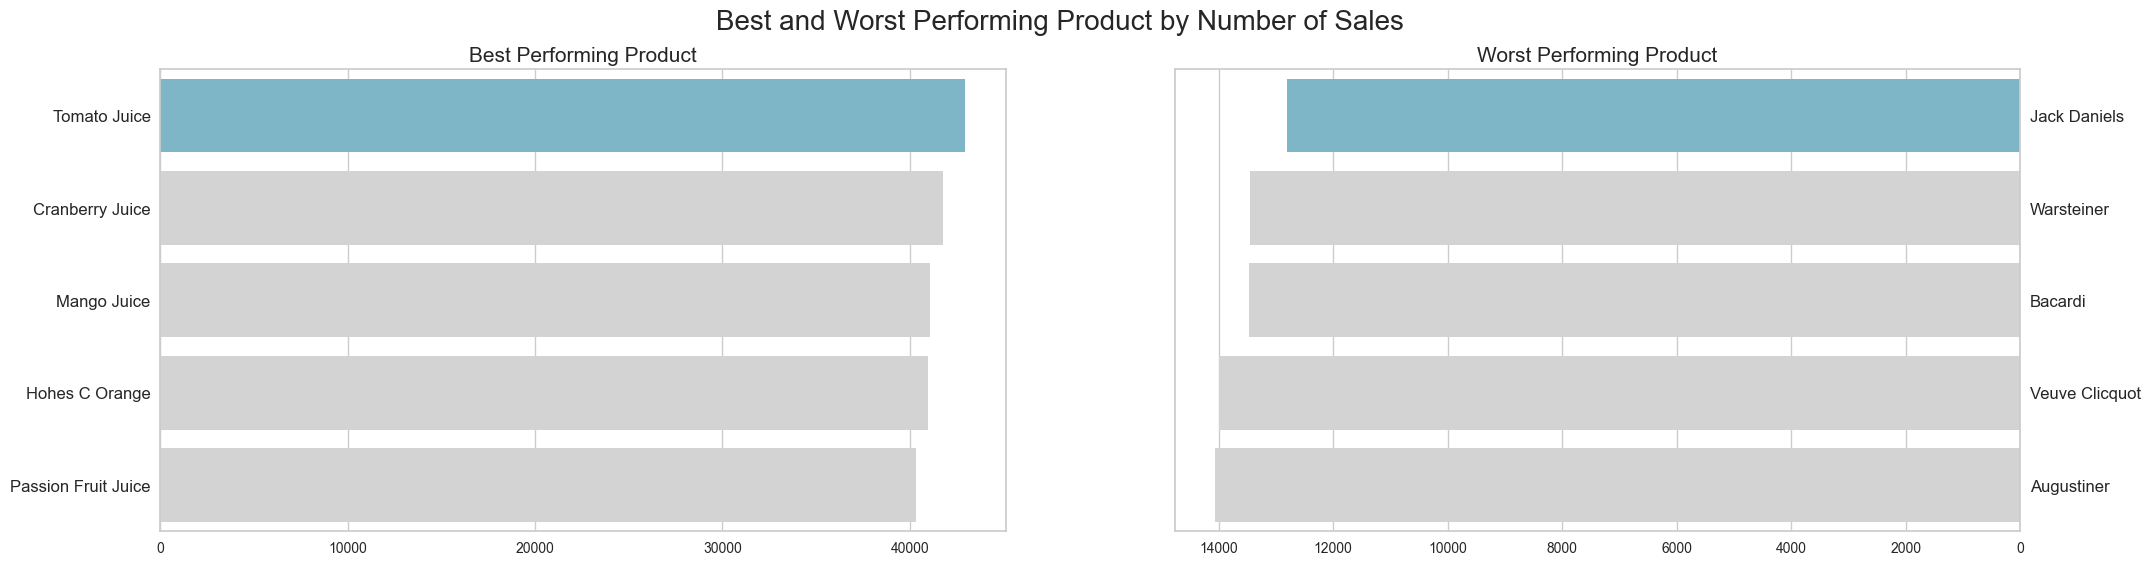

In [62]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
 
sns.barplot(x="Quantity", y="Product", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)
 
sns.barplot(x="Quantity", y="Product", data=sum_order_items_df.sort_values(by="Quantity", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)
 
plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

In [63]:
datetime_columns = ["Order_Date"]

for column in datetime_columns:
    df[column]=pd.to_datetime(df[column])

In [64]:
monthly_orders_df = df.resample(rule='M', on='Order_Date').agg({
    "Order_ID" : "nunique",
    "Total_Price" : "sum"
})
monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')
monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "Order_ID" : "Order_Count",
    "Total_Price" : "Revenue"
}, inplace=True)

monthly_orders_df

C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\4056109011.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = df.resample(rule='M', on='Order_Date').agg({


,Order_Date,Order_Count,Revenue
0,2021-01,488,179004.50
1,2021-02,408,183744.71
2,2021-03,492,171491.60
3,2021-04,456,149649.35
4,2021-05,449,136478.99
5,2021-06,442,161486.33
6,2021-07,454,148827.63
7,2021-08,484,180094.60
8,2021-09,450,150658.85
9,2021-10,453,198937.91


C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\209920166.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\209920166.py:8: UserWarning: 
The palette list has fewer values (8) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


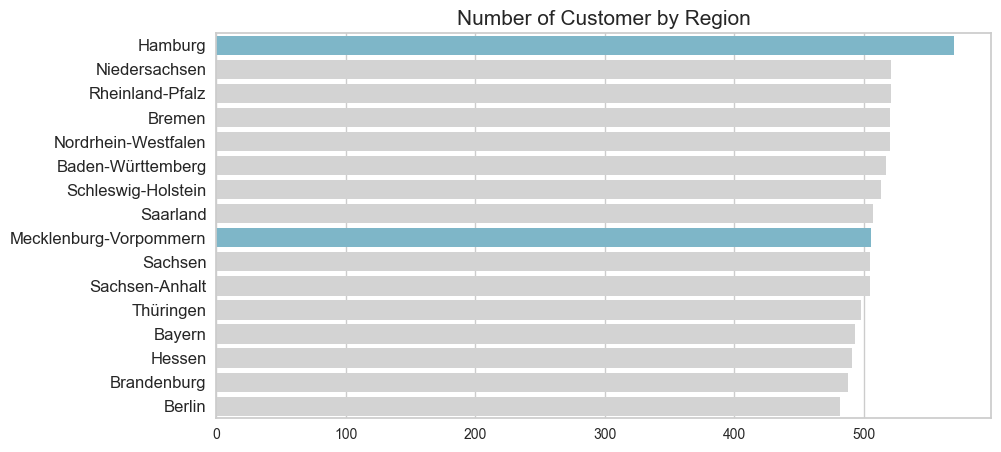

In [65]:
byregion_df = df.groupby(by="Region").Customer_ID.nunique().reset_index()
byregion_df.rename(columns={
    "Customer_ID": "Customer_Count"
}, inplace=True)
byregion_df
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    x="Customer_Count", 
    y="Region",
    data=byregion_df.sort_values(by="Customer_Count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer by Region", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

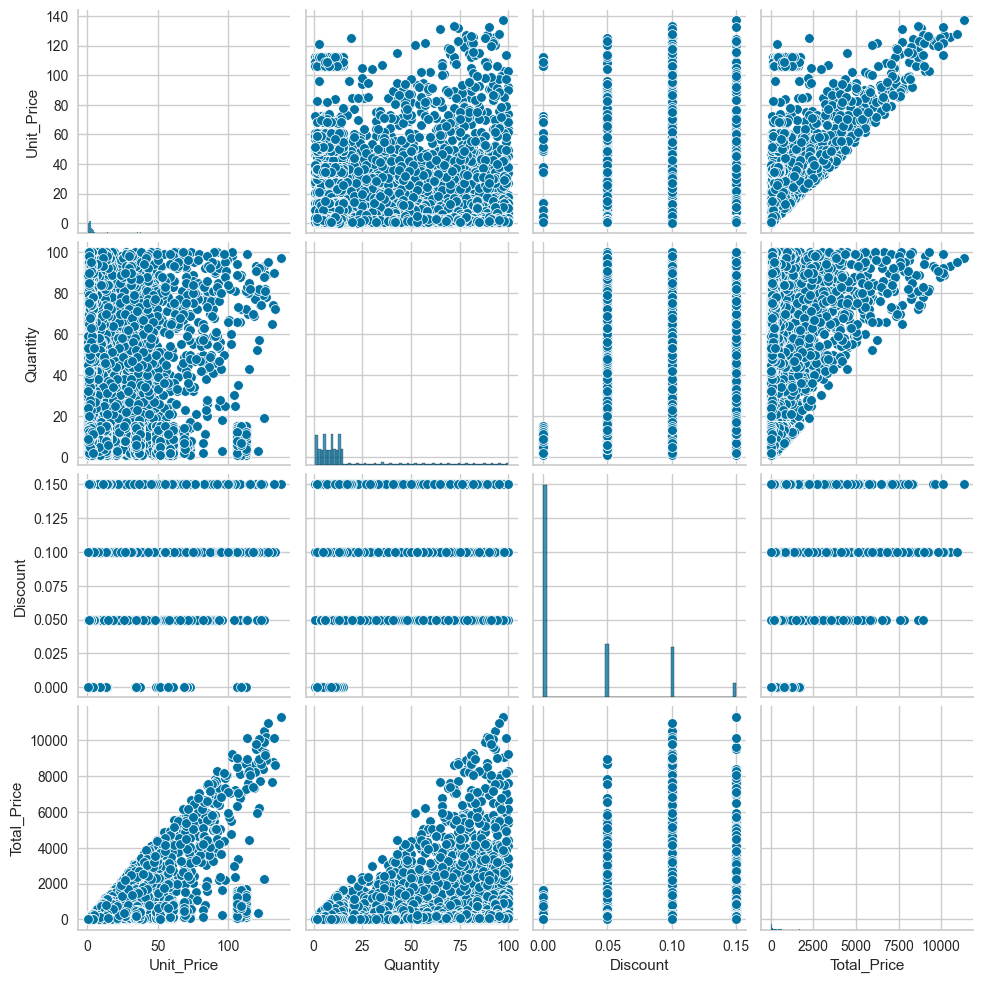

In [66]:
sns.pairplot(df)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [67]:
X_cleaned = df.copy()

Q1 = X_cleaned[int_float_features].quantile(0.25)
Q3 = X_cleaned[int_float_features].quantile(0.75)
IQR = Q3 - Q1
outliers = ((X_cleaned[int_float_features] < (Q1 - 1.5 * IQR)) | (X_cleaned[int_float_features] > (Q3 + 1.5 * IQR))).any(axis=1)
print("\nJumlah Outlier Teridentifikasi:", outliers.sum())
# Menghapus outlier jika diperlukan
X_cleaned = X_cleaned.loc[~outliers]
print("Jumlah Baris Setelah Menghapus Outlier:", X_cleaned.shape[0])


Jumlah Outlier Teridentifikasi: 12177
Jumlah Baris Setelah Menghapus Outlier: 37823


In [69]:
X_cleaned = X_cleaned.drop(['Order_ID', 'Customer_ID'], axis=1)
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
6,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20
7,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20
9,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20


In [70]:
scaler = StandardScaler()
X_cleaned[int_float_features] = scaler.fit_transform(X_cleaned[int_float_features])
print("\nData Numerikal Setelah Normalisasi/Standarisasi:")
print(X_cleaned[int_float_features].head())


Data Numerikal Setelah Normalisasi/Standarisasi:
   Unit_Price  Quantity  Discount  Total_Price
0   -0.124207  2.735597  2.667548     2.212742
4   -0.873491  1.475886  2.667548     0.187121
6    0.331055  2.105741  2.667548     2.430248
7   -1.290814 -0.063761  1.068102    -0.677035
9   -0.389776 -0.763601  1.068102    -0.731020


In [71]:
label_encoders = {}

# Menghapus 'Order_ID' dan 'Customer_ID' dari daftar categorical_features jika ada
categorical_features = [col for col in categorical_features if col not in ['Order_ID', 'Customer_ID']]

for col in categorical_features:
    le = LabelEncoder()
    X_cleaned.loc[:, col] = le.fit_transform(X_cleaned[col])
    label_encoders[col] = le  # Simpan encoder untuk interpretasi nanti

print("\nData Kategorikal Setelah Encoding:")
print(X_cleaned[categorical_features].head())



Data Kategorikal Setelah Encoding:
  Customer_Type Product Category Region  Order_Date
0             0      35        3      0         964
4             0      11        3      0         964
6             0      34        1      5         688
7             0      36        3      5         688
9             0       8        3      5         688


C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\365223205.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[964 964 688 ... 895 131 131]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  X_cleaned.loc[:, col] = le.fit_transform(X_cleaned[col])


In [72]:
X_cleaned[categorical_features].tail()

,Customer_Type,Product,Category,Region,Order_Date
49995,1,6,1,6,895
49996,1,22,1,6,895
49997,1,0,3,6,895
49998,1,26,0,10,131
49999,1,32,3,10,131


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

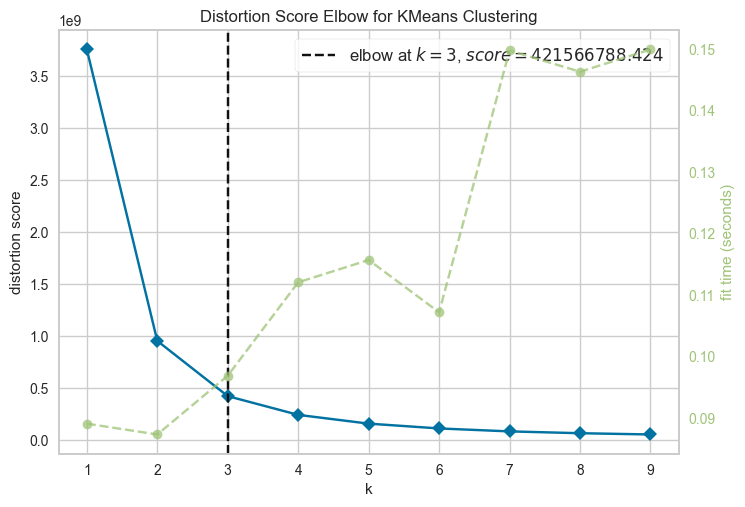

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [73]:
# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()
 
# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
 
# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X_cleaned)
 
# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [74]:
# Pilih jumlah cluster awal (misalnya, 2)
n_clusters = 2

# Latih model clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

Jumlah klaster: 2, Silhouette Score: 0.6203187716482698 - Disimpan
Jumlah klaster: 3, Silhouette Score: 0.584714791805536 - Disimpan


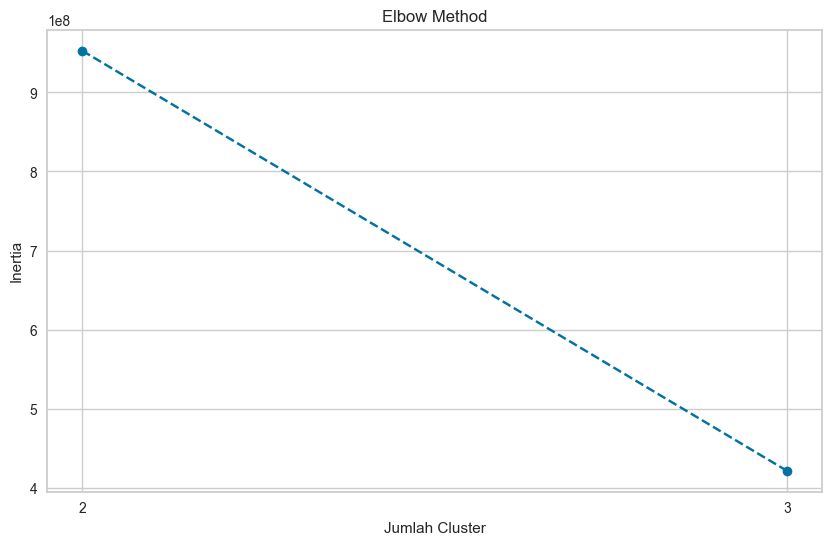

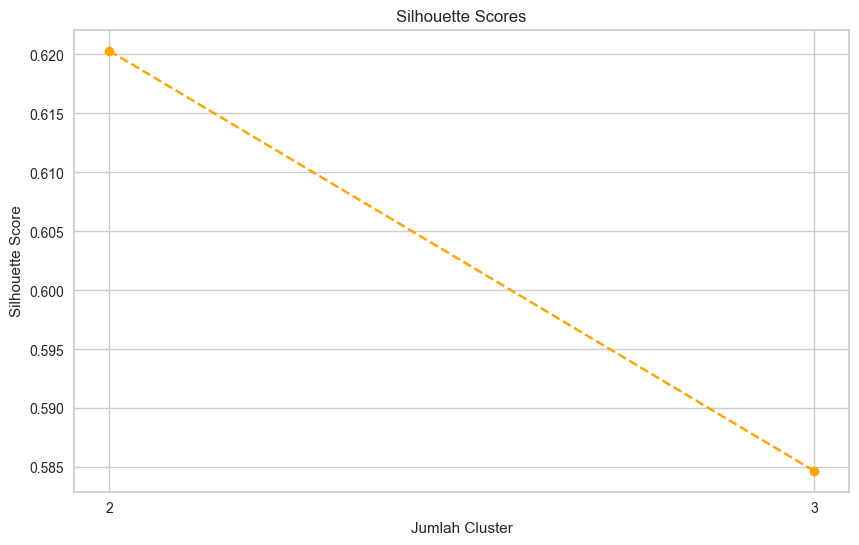


Jumlah cluster optimal berdasarkan Silhouette Score: 2


In [75]:
# Elbow Method untuk menentukan jumlah cluster optimal
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 4)  # Uji jumlah cluster dari 2 hingga 4

# Variabel untuk menyimpan label klaster yang valid
valid_cluster_labels = []

for n_clusters in range_n_clusters:
    # Melakukan klasterisasi KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_cleaned)

    # Menghitung Silhouette Score untuk hasil klasterisasi
    silhouette_avg = silhouette_score(X_cleaned, cluster_labels)

    # Simpan inertia (SSE) untuk Elbow Method
    inertia.append(kmeans.inertia_)

    # Hitung silhouette score
    score = silhouette_score(X_cleaned, cluster_labels)
    silhouette_scores.append(score)

    # Jika Silhouette Score >= 0.55, simpan label klaster
    if silhouette_avg >= 0.55:
        valid_cluster_labels.append(cluster_labels)
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg} - Disimpan")
    else:
        print(f"Jumlah klaster: {n_clusters}, Silhouette Score: {silhouette_avg} - Tidak Disimpan")

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='orange')
plt.title('Silhouette Scores')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.show()

# Pilih jumlah cluster optimal berdasarkan evaluasi
optimal_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 karena range dimulai dari 2
print(f"\nJumlah cluster optimal berdasarkan Silhouette Score: {optimal_n_clusters}")

In [76]:
# Assign optimal clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)
X_cleaned['Cluster'] = kmeans.fit_predict(X_cleaned)

# Menampilkan DataFrame dengan hasil klasterisasi
print(X_cleaned)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

In [77]:
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,0,35,3,-0.124207,2.735597,2.667548,2.212742,0,964,1
4,0,11,3,-0.873491,1.475886,2.667548,0.187121,0,964,1
6,0,34,1,0.331055,2.105741,2.667548,2.430248,5,688,1
7,0,36,3,-1.290814,-0.063761,1.068102,-0.677035,5,688,1
9,0,8,3,-0.389776,-0.763601,1.068102,-0.731020,5,688,1


C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\2440003535.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


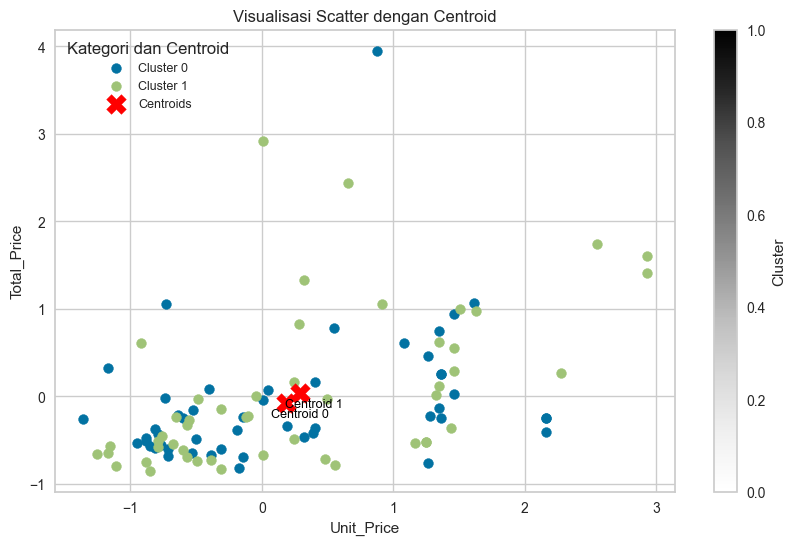

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Mengambil 10 sampel data secara acak
sampled_data = X_cleaned.sample(n=100, random_state=42)

# Pilih kolom untuk sumbu X dan Y
x_column = "Unit_Price"  # Ganti dengan nama kolom yang diinginkan untuk sumbu X
y_column = "Total_Price"  # Ganti dengan nama kolom yang diinginkan untuk sumbu Y

# Menghitung centroid untuk setiap cluster
centroids = sampled_data.groupby('Cluster')[[x_column, y_column]].mean()

# Visualisasi scatter plot
plt.figure(figsize=(10, 6))

# Plot titik data berdasarkan cluster
for cluster_label in sampled_data['Cluster'].unique():
    cluster_data = sampled_data[sampled_data['Cluster'] == cluster_label]
    plt.scatter(
        cluster_data[x_column],
        cluster_data[y_column],
        label=f'Cluster {cluster_label}',  # Label untuk legend
        cmap='viridis',
        s=50
    )

# Tambahkan centroid ke plot
plt.scatter(
    centroids[x_column],
    centroids[y_column],
    color='red',
    s=200,
    marker='X',
    label='Centroids'
)

# Anotasi centroid
for cluster_label, coord in centroids.iterrows():
    plt.annotate(
        f'Centroid {cluster_label}',
        (coord[x_column], coord[y_column]),
        textcoords="offset points",
        xytext=(10, -10),
        ha='center',
        fontsize=9,
        color='black'
    )

# Menambahkan elemen visualisasi
plt.title('Visualisasi Scatter dengan Centroid')
plt.colorbar(label='Cluster')
plt.xlabel(f'{x_column}')
plt.ylabel(f'{y_column}')
plt.legend(title="Kategori dan Centroid", loc="upper left", fontsize=9)
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [79]:
for col in categorical_features:
    le = label_encoders[col]
    # Pastikan tipe data integer sebelum inverse_transform
    X_cleaned.loc[:, col] = le.inverse_transform(X_cleaned[col].astype(int))

C:\Users\hanzk\AppData\Local\Temp\ipykernel_11312\2454076519.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2023-08-23T00:00:00.000000000' '2023-08-23T00:00:00.000000000'
 '2022-11-20T00:00:00.000000000' ... '2023-06-15T00:00:00.000000000'
 '2021-05-12T00:00:00.000000000' '2021-05-12T00:00:00.000000000']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_cleaned.loc[:, col] = le.inverse_transform(X_cleaned[col].astype(int))


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [80]:
X_cleaned[int_float_features] = scaler.inverse_transform(X_cleaned[int_float_features])

In [81]:
X_cleaned.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,B2B,Vio Wasser,Water,1.66,53.0,0.10,79.18,Baden-Württemberg,2023-08-23,1
4,B2B,Gerolsteiner,Water,0.87,35.0,0.10,27.40,Baden-Württemberg,2023-08-23,1
6,B2B,Tomato Juice,Juices,2.14,44.0,0.10,84.74,Hamburg,2022-11-20,1
7,B2B,Vittel,Water,0.43,13.0,0.05,5.31,Hamburg,2022-11-20,1
9,B2B,Evian,Water,1.38,3.0,0.05,3.93,Hamburg,2022-11-20,1


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

        Unit_Price                    Quantity                    Discount  \
              mean median       std       mean median        std      mean   
Cluster                                                                      
0         1.757901   1.54  1.039483  13.799228   10.0  14.190244  0.016253   
1         1.823137   1.63  1.067675  14.019984   10.0  14.384378  0.016958   

                         Total_Price                    
        median       std        mean median        std  
Cluster                                                 
0          0.0  0.030965   22.045308  13.68  25.027825  
1          0.0  0.031544   23.173020  14.31  26.061824  
        Customer_Type             Product     Category   Region Order_Date
Cluster                                                                   
0                 B2C      Hohes C Orange        Water  Sachsen 2021-06-16
1                 B2C  Rauch Multivitamin  Soft Drinks  Hamburg 2023-10-15


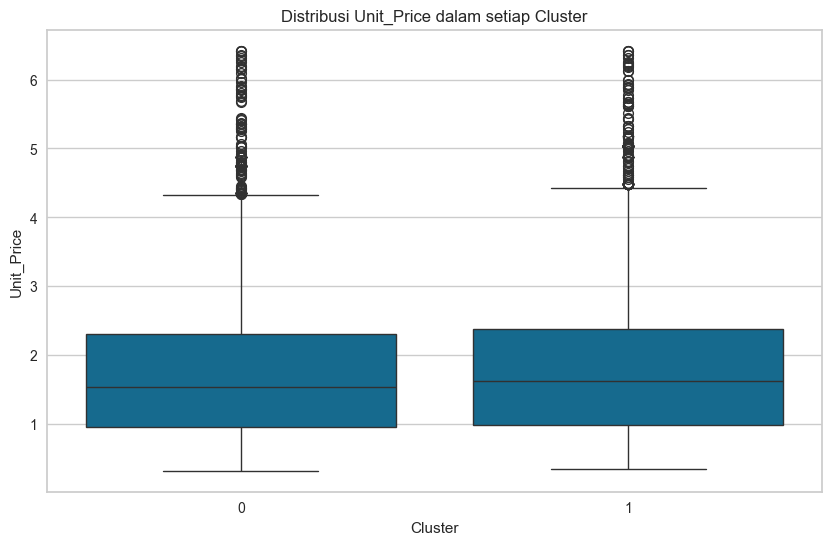

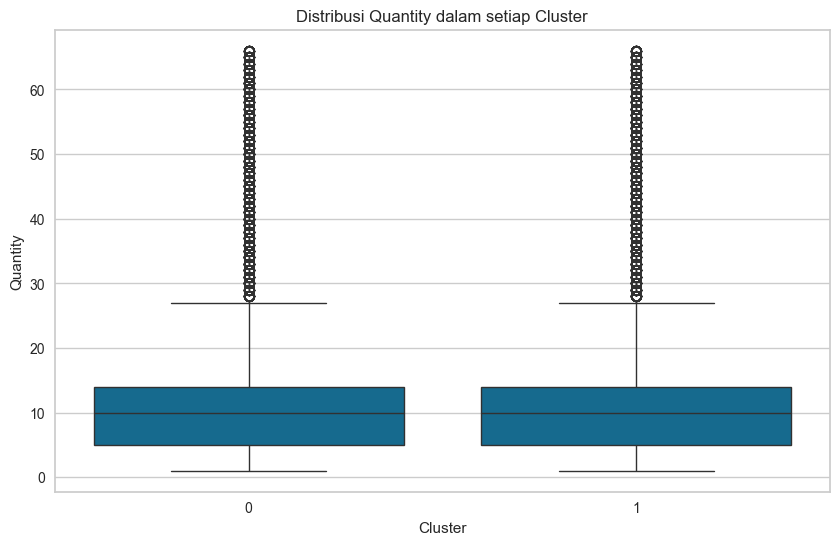

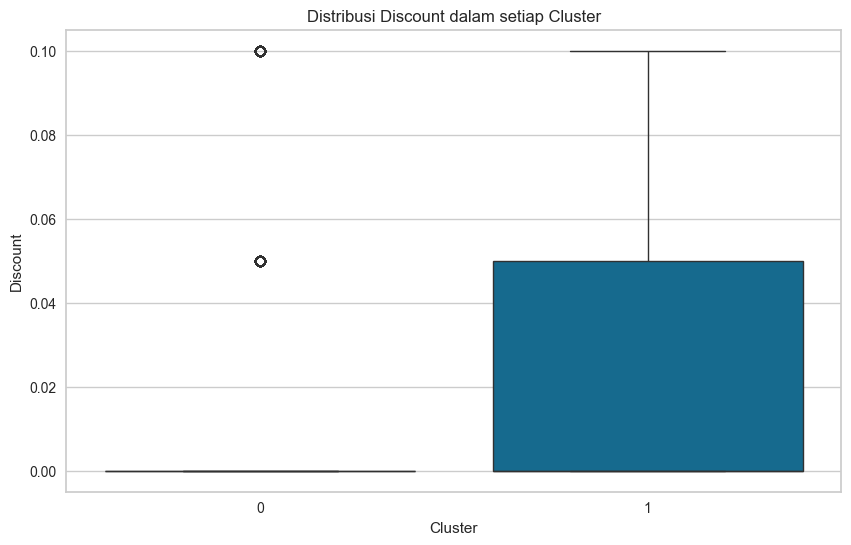

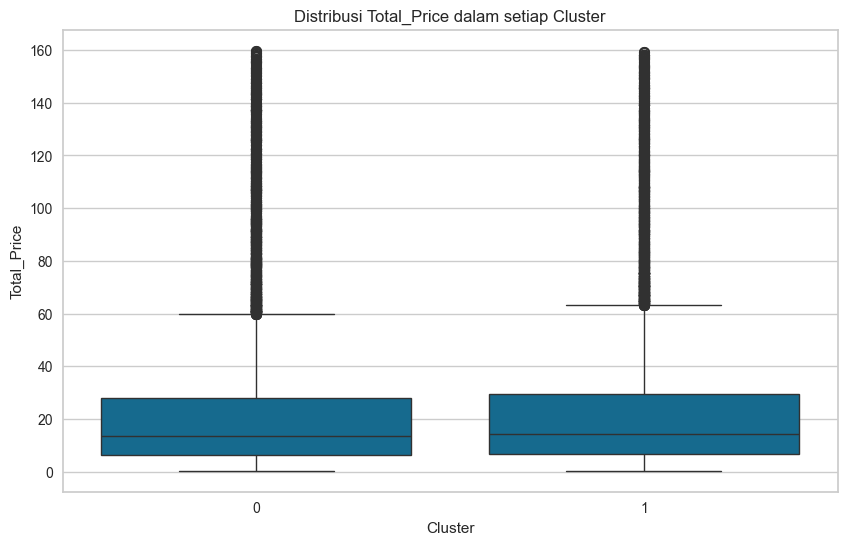

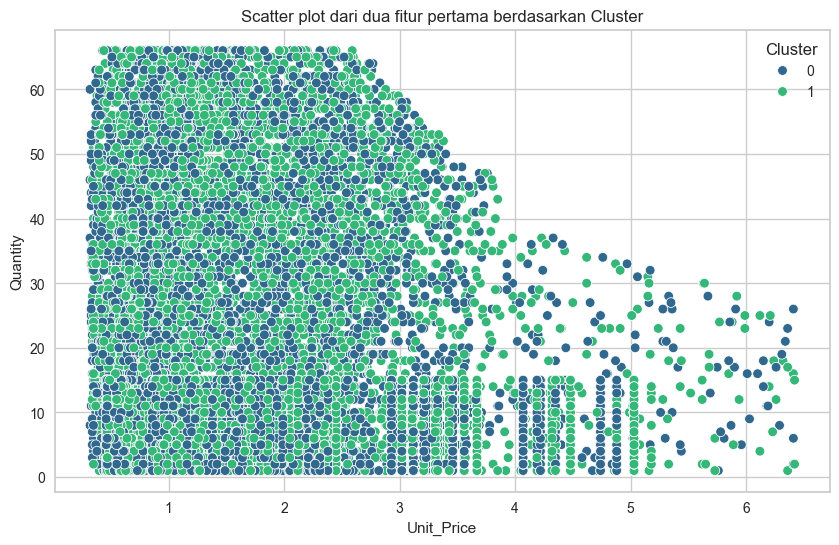

In [82]:
# Misalkan df adalah DataFrame yang memiliki hasil clustering
# df['Cluster'] adalah kolom yang berisi label cluster

# Menghitung statistik deskriptif untuk kolom numerik saja
cluster_summary = X_cleaned.groupby('Cluster')[int_float_features].agg(['mean', 'median', 'std'])
print(cluster_summary)

# Menghitung mode untuk setiap fitur kategorikal
cat_summary = X_cleaned.groupby('Cluster')[categorical_features].agg(lambda x: x.mode().iloc[0])
print(cat_summary)

# Visualisasi distribusi nilai dalam setiap cluster menggunakan boxplot
for col in int_float_features:
    if col != 'Cluster':
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Cluster', y=col, data=X_cleaned)
        plt.title(f'Distribusi {col} dalam setiap Cluster')
        plt.show()

# Visualisasi scatter plot untuk dua fitur pertama
plt.figure(figsize=(10, 6))
sns.scatterplot(x=int_float_features[0], y=int_float_features[1], hue='Cluster', data=X_cleaned, palette='viridis')
plt.title('Scatter plot dari dua fitur pertama berdasarkan Cluster')
plt.show()


# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0:
- **Mean Unit Price:** 1.757901
- **Mean Quantity:** 13.799228
- **Mean Unit Discount:** 0.016253
- **Mean Total Price:** 22.027825
- **Karakteristik Pelanggan:**
    - **Customer Type:** B2C (Business to Customer)
    - **Product:** Hohes C Orange
    - **Category:** Water
    - **Region:** Sachsen
- **Analisis:** Cluster 0 terdiri dari pelanggan dengan rata-rata harga satuan sebesar 1.757901, yang sedikit lebih rendah dibandingkan cluster lain. Median harga satuan adalah 1.54 dengan penyimpangan sebesar 1.039483, menunjukkan adanya variasi harga dalam kelompok ini. Pelanggan rata-rata membeli 13.799228 produk dengan median sebanyak 10 dan penyimpangan sebanyak 14.190244, menandakan adanya fluktuasi dalam jumlah pembelian. Diskon rata-rata yang diberikan kecil, yaitu 0.016253, dengan median 0.0. Total pembelian rata-rata mencapai 22.045308 dengan median 13.68 dan penyimpangan sebesar 25.027825. Pelanggan dalam cluster ini kebanyakan berasal dari wilayah Sachsen dan termasuk dalam tipe pelanggan B2C. Produk yang paling dominan adalah Hohes C Orange dalam kategori Water, dengan tanggal pembelian yang banyak terjadi pada 16 Juni 2021. Pola ini menunjukkan bahwa pelanggan di cluster ini cenderung membeli produk dalam jumlah moderat untuk kebutuhan individu.

## Cluster 1:
- **Mean Unit Price:** 1.823137
- **Mean Quantity:** 14.019984
- **Mean Unit Discount:** 0.016958
- **Mean Total Price:** 23.173020
- **Karakteristik Pelanggan:**
    - **Customer Type:** B2C (Business to Customer)
    - **Product:** Rauch Multivitamin
    - **Category:** Soft Drinks
    - **Region:** Hamburg
- **Analisis:** Cluster 1 terdiri dari pelanggan dengan rata-rata harga satuan sebesar 1.823137, sedikit lebih tinggi dari Cluster 0. Median harga satuan adalah 1.63 dengan penyimpangan sebesar 1.067675, menandakan adanya variasi harga dalam cluster ini. Jumlah rata-rata produk yang dibeli adalah 14.019984 dengan median sebanyak 10 dan penyimpangan sebesar 14.384378, menunjukkan pola pembelian yang stabil dengan beberapa fluktuasi. Diskon rata-rata yang diberikan sebesar 0.016958, dengan median 0.0. Total pembelian rata-rata mencapai 23.173020 dengan median 14.31 dan penyimpangan sebesar 26.061824. Pelanggan dalam cluster ini juga termasuk tipe B2C dan dominan membeli produk Rauch Multivitamin dalam kategori Soft Drinks. Sebagian besar pelanggan berasal dari wilayah Hamburg dan banyak melakukan pembelian pada 15 Oktober 2023. Cluster ini menggambarkan pelanggan dengan pola pembelian yang mirip dengan Cluster 0 tetapi memiliki preferensi terhadap produk kategori Soft Drinks.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [83]:
# Simpan dataset ke dalam file CSV
output_file = 'hasil_clustering.csv'
X_cleaned.to_csv(output_file, index=False)